# Chatbot Performance Evaluation

This notebook evaluates the response time of the chatbot.
It compares two scenarios:
1.  **With RAG**: Using Mental Health related questions (from `src/evaluation/rag/raw_qa.txt`).
2.  **Without RAG**: Using General Chat questions (e.g., simple math, greetings).

The evaluation measures the end-to-end latency of the API call.

In [25]:
import requests
import uuid
import time
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import List, Dict, Any

# Configuration
API_URL = "https://orchestrator.khanklee.id.vn/chat"
RAW_QA_FILE = "raw_qa.txt"  # Relative path from src/evaluation/performance/

# Ensure we can find the file relative to the notebook location
import os

print(f"Using QA file: {RAW_QA_FILE}")

Using QA file: raw_qa.txt


## 1. Data Preparation

In [26]:
def parse_raw_qa(file_path: str) -> List[str]:
    """Parse raw Q/A file and return list of questions."""
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Regex to find questions starting with Q<number>:
    # Matches "Q1: Question text" until newline
    questions = re.findall(r"Q\d+\s*:\s*(.+)", content)
    return [q.strip() for q in questions]

# Load RAG questions
rag_questions = parse_raw_qa(RAW_QA_FILE)
print(f"Loaded {len(rag_questions)} RAG questions.")
for i, q in enumerate(rag_questions[:3]):
    print(f"  {i+1}. {q}")

Loaded 20 RAG questions.
  1. Stress có thể biểu hiện như thế nào về mặt cảm xúc?
  2. Stress ảnh hưởng như thế nào đến hành vi?
  3. Stress có phải lúc nào cũng xấu không?


In [27]:
# Define General Questions (No RAG expected)
general_questions = [
    "Xin chào, bạn là ai?",
    "1 + 1 bằng mấy?",
    "Kể cho tôi nghe một câu chuyện cười.",
    "Hôm nay trời đẹp không?",
    "Bạn có thể làm thơ không?",
    "Thủ đô của Việt Nam là gì?",
    "Mặt trời mọc hướng nào?",
    "Nước sôi ở bao nhiêu độ?",
    "Chúc bạn một ngày tốt lành!",
    "Cristiano Ronaldo là ai?",
    "Messi là ai?",
    "Thủ đô của Pháp là gì?",
    "Thủ đô của Maroc là gì?",
    "Thủ đô của Chile là gì?",
    "Dân số Việt Nam có bao nhiêu người?",
    "Châu lục nào đông dân nhất?",
    "Ai là người có nhiều danh hiệu Champions League nhất?",
    "Câu lạc bộ Chelsea thuộc quốc gia nào?",
    "Câu lạc bộ châu Âu nào có nhiều danh hiệu Champions League nhất?",
    "Thành phố Hồ Chí Minh thuộc nước nào?"
]
print(f"Defined {len(general_questions)} General questions.")

Defined 20 General questions.


## 2. Evaluation Logic

In [28]:
def evaluate_question(question: str, category: str) -> Dict[str, Any]:
    """Send question to API and measure latency."""
    user_id = str(uuid.uuid4())
    session_id = str(uuid.uuid4())
    
    payload = {
        "message": question,
        "user_id": user_id,
        "session_id": session_id
    }
    
    start_time = time.time()
    try:
        response = requests.post(API_URL, json=payload, timeout=30)
        latency = time.time() - start_time
        
        if response.status_code == 200:
            data = response.json()
            return {
                "question": question,
                "category": category,
                "latency": latency,
                "timestamp": start_time,
                "status": "success",
                "selected_agent": data.get("selected_agent"),
                "response_length": len(data.get("response", "") or "")
            }
        else:
            return {
                "question": question,
                "category": category,
                "latency": latency,
                "timestamp": start_time,
                "status": f"error_{response.status_code}",
                "selected_agent": None,
                "response_length": 0
            }
    except Exception as e:
        latency = time.time() - start_time
        return {
            "question": question,
            "category": category,
            "latency": latency,
            "timestamp": start_time,
            "status": f"exception_{str(e)}",
            "selected_agent": None,
            "response_length": 0
        }

## 3. Run Evaluation

In [29]:
results = []

print("Starting Evaluation...")

# Evaluate RAG Questions
print("\nTesting RAG Questions (Mental Health)...")
for q in rag_questions:
    print(f"  Sending: {q[:50]}...")
    res = evaluate_question(q, "RAG (Mental Health)")
    results.append(res)
    time.sleep(1) # Sleep to avoid rate limiting

# Evaluate General Questions
print("\nTesting General Questions (No RAG)...")
for q in general_questions:
    print(f"  Sending: {q[:50]}...")
    res = evaluate_question(q, "No RAG (General)")
    results.append(res)
    time.sleep(1)

print("\nEvaluation Complete.")

Starting Evaluation...

Testing RAG Questions (Mental Health)...
  Sending: Stress có thể biểu hiện như thế nào về mặt cảm xúc...
  Sending: Stress ảnh hưởng như thế nào đến hành vi?...
  Sending: Stress có phải lúc nào cũng xấu không?...
  Sending: Khi bị stress, cơ thể thường có phản ứng ra sao?...
  Sending: Sinh viên thường bị stress trong những tình huống ...
  Sending: Làm thế nào để phòng ngừa và kiểm soát stress hiệu...
  Sending: Lo âu là gì?...
  Sending: Lo âu có thể xuất phát từ đâu?...
  Sending: Người bị lo âu thường có những biểu hiện tâm lý nà...
  Sending: Khi bị lo âu, cơ thể thường phản ứng ra sao?...
  Sending: Lo âu ảnh hưởng như thế nào đến cuộc sống của sinh...
  Sending: Khi nào nên tìm gặp chuyên gia nếu gặp phải lo âu?...
  Sending: Sinh viên có thể làm gì để giảm bớt lo âu?...
  Sending: Trầm cảm là gì?...
  Sending: Khi nào một người được xem là mắc trầm cảm?...
  Sending: Người bị trầm cảm thường có những biểu hiện cảm xú...
  Sending: Trầm cảm ảnh hưởng nh

## 4. Analysis

Total Requests: 40
Successful Requests: 39

Latency Statistics:


,Count,Mean (s),Median (s),Min (s),Max (s),P95 (s)
category,,,,,,
No RAG (General),19,1.479803,1.336939,1.102435,2.342374,2.182479
RAG (Mental Health),20,14.342799,14.064797,10.899652,18.964438,16.769220



Agent Selection Distribution:
category             selected_agent
No RAG (General)     null              19
RAG (Mental Health)  RAG Agent         20
dtype: int64


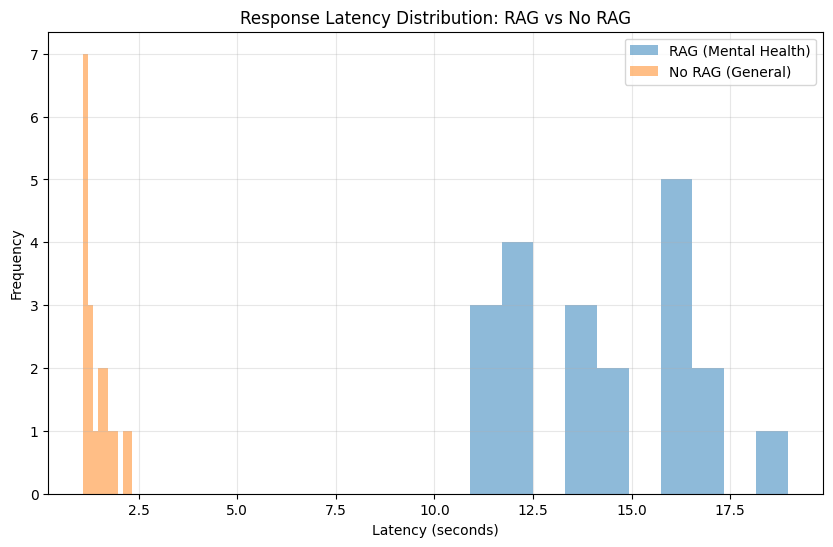

<Figure size 800x600 with 0 Axes>

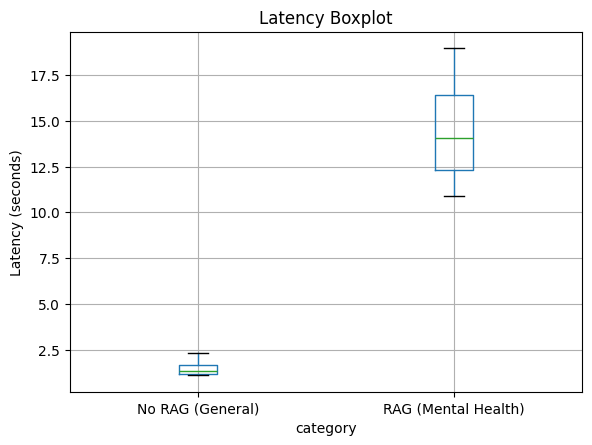

In [30]:
df = pd.DataFrame(results)

# Filter successful requests
df_success = df[df['status'] == 'success']

print(f"Total Requests: {len(df)}")
print(f"Successful Requests: {len(df_success)}")

if not df_success.empty:
    # Group by category
    stats = df_success.groupby('category')['latency'].agg(['count', 'mean', 'median', 'min', 'max', lambda x: np.percentile(x, 95)])
    stats.columns = ['Count', 'Mean (s)', 'Median (s)', 'Min (s)', 'Max (s)', 'P95 (s)']
    print("\nLatency Statistics:")
    display(stats)
    
    # Check Agent Selection Accuracy (Heuristic)
    print("\nAgent Selection Distribution:")
    print(df_success.groupby(['category', 'selected_agent']).size())

    # Visualization 1: Histogram
    plt.figure(figsize=(10, 6))
    for category in df_success['category'].unique():
        subset = df_success[df_success['category'] == category]
        plt.hist(subset['latency'], alpha=0.5, label=category, bins=10)
    
    plt.xlabel('Latency (seconds)')
    plt.ylabel('Frequency')
    plt.title('Response Latency Distribution: RAG vs No RAG')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Visualization 2: Boxplot
    plt.figure(figsize=(8, 6))
    df_success.boxplot(column='latency', by='category')
    plt.title('Latency Boxplot')
    plt.suptitle('')
    plt.ylabel('Latency (seconds)')
    plt.show()
else:
    print("No successful requests to analyze.")